# load files

## Measurement data

### summarizing all of the non-sequencing data in `measurements/*.csv`
- VFA.csv: Contains Acetate, Propionate, Butyrate, and COD for the reactor, waste, and media
- Ammonia.csv: Ammonia concentrations in the reactor, waste, and media
- TSS_VSS.csv: Abundances of TSS & VSS in the system
- Pre-Summary.csv: Defining sampling codes as days of operation
- GC_TCD.csv: gaseous components of various reactors
- Summary.csv: `main content`.  Complete gaseous ins/outs, carbon accounting, occasional media VFA and TSS measurements

In [ ]:
from pandas import read_excel

measurements = read_excel("model_inputs/measurements.xlsx", engine='openpyxl', sheet_name=None)
print(len(measurements))
for sheetName, csv in measurements.items():
    csv.to_csv(f"model_inputs/{sheetname}.csv")

### Process Summary.csv

In [9]:
from pandas import api, read_csv, set_option
from json import load, dump

summary = read_csv("model_inputs/measurements/Summary.csv", header=1
                  ).set_index("Days of Operation").drop(["0", "2024-05-14 12:42:00"], axis=1)
for col in summary.columns:
    # Skip non-numeric columns
    if not api.types.is_numeric_dtype(summary[col]):
        continue
        
    series = summary[col]
    # Skip if no missing values
    if not series.isna().any():
        continue
    # Skip if all values are missing (can't interpolate)
    if series.isna().all():
        continue
    summary[col] = series.interpolate(
        method='linear',
        limit_direction='forward',
        limit_area='inside'  # Only fill NaN values inside valid values (not at edges)
    )

summary.iloc[0:4, 5:9] = summary.iloc[5, 5:9].values
summary.loc[300, "Biomass Sample ID"] = "Q"
summary_samples = summary[summary["Biomass Sample ID"].notna()]
summary_samples.set_index("Biomass Sample ID", inplace=True)
# display(summary_samples) #summary.loc["300"])
summary.to_csv("model_inputs/measurements/Summary_interpolated.csv")
dic = summary_samples.T.to_dict()
display(list(dic.items())[0])
dump(dic, open("model_inputs/measurements/summary_samples.json", 'w'), indent=3)

('10AB',
 {'Media description': 'DSMZ v1: Using DSMZ 120 without NaHCO3',
  'Media changes': 1.0,
  'Media Influent Flow Rate (mL/min) based on scales linear projection': 0.0592216175,
  'pH adjustment delivery rate (mL/min) - primarily 1 M HCl, sometimes 1 M NaOH': 0.0,
  'Media Acetate (mol/L)': 0.0354271680216802,
  'Media Propionate (mol/L)': 0.0022489849915606,
  'Media Butyrate (mol/L)': nan,
  'Media Total VFA (mg COD/L)': 2480.559206666667,
  'Media Total COD (mg/L) Hach': 17545.426063635256,
  'Media Ammonia (mol/L)': nan,
  'Media Dissolved Inorganic Carbon (mol C/L)': nan,
  'Media Dissolved Organic Carbon (mol C/L)': nan,
  'Approximate Total Influent C (mol/min) based on Media recipe': 2.6705660146199203e-05,
  'H2 delivery rate setpoint (mL/min)': 1.0915248032216731,
  'CO2 delivery rate setpoint (mL/min)': 0.25,
  'H2 delivery rate (mol/min)': 4.872878585811041e-05,
  'H2 delivery rate (e-eq/min)': 0.0002680083222196,
  'H2 delivery (g COD/min)': 0.0124745691796762,
  'C

### ModelSEED compounds for these column names

In [ ]:
summary_key_to_modelseed = {

    # ---- MEDIA COMPOUNDS ----
    "Media Acetate (mol/L)": "cpd00029",        # acetate
    "Media Propionate (mol/L)": "cpd00141",     # propionate
    "Media Butyrate (mol/L)": "cpd00211",       # butyrate
    "Media Ammonia (mol/L)": "cpd00013",        # NH3/NH4+
    "Media Dissolved Inorganic Carbon (mol C/L)": "cpd00011",  # CO2 (aq)
    
    # ---- GAS FEED ----
    "H2 delivery rate (mol/min)": "cpd00067",   # hydrogen
    "CO2 delivery rate (mol/min)": "cpd00011",  # carbon dioxide

    # ---- WASTE / EFFLUENT COMPOUNDS ----
    "Waste Effluent Acetate (mol/L)": "cpd00029",
    "Waste Effluent Propionate (mol/L)": "cpd00141",
    "Waste Effluent Butyrate (mol/L)": "cpd00211",
    "Waste Effluent Ammonia (mol/L)": "cpd00013",
    "Waste Effluent Dissolved Inorganic Carbon (mol C/L)": "cpd00011",
    "Waste Effluent Dissolved Organic Carbon (mol C/L)": "cpd00027",  # generic glucose-equivalent DOC proxy

    # ---- GAS PHASE ----
    "Gas Composition (% CH4)": "cpd00104",      # methane
    "Gas Composition (% H2)": "cpd00067",
    "Gas Composition (% CO2)": "cpd00011",
    "CH4 Production (mol/min)": "cpd00104",
    "H2 breakthrough (mol/min)": "cpd00067",
    "CO2 breakthrough (mol/min)": "cpd00011",

    # ---- AQUEOUS CARBONATE SPECIATION ----
    "[CO2aq]": "cpd00011",
    "[HCO3-]": "cpd00099",   # bicarbonate
    "[CO3-2]": "cpd00060",  # carbonate

}


## Taxonomy and Abundance data

In [22]:
from pandas import read_csv
from json import load, dump

# Abundance
ab = read_csv("model_inputs/abundances.csv").set_index("seq")
## NOTE: filtering for abundance here saves compute later by not pulling and processing genomes for ASVs that are then filtered 
meaningful_ASVs = ab[(ab > 0.001).any(axis=1)]
print(len(ab)-len(meaningful_ASVs), "negligible abundance ASVs")
display(meaningful_ASVs)
ab_js = meaningful_ASVs.to_dict()
dump(ab_js, open("model_inputs/abundances.json", "w"), indent=2)

# Taxonomy
df = read_csv('model_inputs/taxonomy.csv').set_index('seq').drop("sample", axis=1)#.fillna(None)
df = df.where(df.notna(), None)
taxonomy_js = {}
for i, row in df.iterrows():
    if i not in meaningful_ASVs.index:
        # print("skipping low abundance", i)
        continue
    taxonomy_js.setdefault(i, {})
    taxonomy_js[i]["Kingdom"] = row["Kingdom"]
    taxonomy_js[i]["Phylum"] = row["Phylum"]
    taxonomy_js[i]["Class"] = row["Class"]
    taxonomy_js[i]["Order"] = row["Order"]
    taxonomy_js[i]["Family"] = row["Family"]
    taxonomy_js[i]["Genus"] = row["Genus"]
    taxonomy_js[i]["Species"] = row["Species"]
display(list(taxonomy_js.items())[:3])
dump(taxonomy_js, open("model_inputs/taxonomy.json", "w"), allow_nan=False, indent=4)

358 negligible abundance ASVs


,10AB,A34,B34,C3,D34,E34,F34,G12,G3,H34,I34,J12,J34,K12,L12,M12,N12,P12,Q
seq,,,,,,,,,,,,,,,,,,,
2c8630b0baf30f2cc97a2f0b4bc96aca,0.000000,0.0,0.0,0.006698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
593b39ccba286d62eba7872e07c45354,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00253,0.0
e9610e4b261eb260ad4e507e8c1d634e,0.015624,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
8a86fb52c58e6597a806872e474d6ac1,0.010858,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
090b23760e2b4c99732ad0ce04fa8ac2,0.002119,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f824c242da3d47edd62495a6a144912c,0.006091,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3f19effc21f49ca3bfe5e130ea113a75,0.005561,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
df443df991086de26795466fa2bdd4f2,0.027012,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


[('0fec351445f84bd482075ceda6123f46',
  {'Kingdom': 'Archaea',
   'Phylum': 'Euryarchaeota',
   'Class': 'Methanobacteria',
   'Order': 'Methanobacteriales',
   'Family': 'Methanobacteriaceae',
   'Genus': 'Methanobacterium',
   'Species': 'midas_s_9526'}),
 ('7f78afb7e1d45cd528fe9cd909c93fb5',
  {'Kingdom': 'Archaea',
   'Phylum': 'Euryarchaeota',
   'Class': 'Methanobacteria',
   'Order': 'Methanobacteriales',
   'Family': 'Methanobacteriaceae',
   'Genus': 'Methanobacterium',
   'Species': None}),
 ('63f37ee4b481fccdffca10160ed5b944',
  {'Kingdom': 'Archaea',
   'Phylum': 'Euryarchaeota',
   'Class': 'Methanobacteria',
   'Order': 'Methanobacteriales',
   'Family': 'Methanobacteriaceae',
   'Genus': None,
   'Species': None})]

In [22]:
# from json import load, dump
# IDmd5 = load(open("model_inputs/ID_md5.json", 'r'))
# dump({v: k.split()[1].split(".rna")[0] for k,v in IDmd5.items()}, open("model_inputs/md5_ID.json", 'w'), indent=2)
# list(IDmd5.items())[:2]

[('fig|2364649.4.rna.62|GCM10009504_r00040| SSU rRNA ## 16S rRNA, small subunit ribosomal RNA [Pseudomonas laurentiana strain JCM 32154 | 2364649.4]',
  '3aa91ee3decd52a4ec32e06cd80d5ac9'),
 ('fig|485.6304.rna.51| SSU rRNA ## 16S rRNA, small subunit ribosomal RNA [Neisseria gonorrhoeae SRR1661269 | 485.6304]',
  'c598154bc9027be784d91ac9674bbe0b')]

# Taxonomy

### Create iterative IDs

In [25]:
from collections import Counter
from json import dump, load
midas_taxonomy = load(open("model_inputs/taxonomy.json",'r'))

# ASV_genera = {ASV: taxa["Genus"] for ASV, taxa in midas_taxonomy.items()}
# display(ASV_genera)
# display({k:v for k,v in Counter(ASV_genera.values()).most_common() if v > 2})
genera_counts = Counter([x["Genus"] for x in midas_taxonomy.values()]) 
display({k:v for k,v in genera_counts.most_common() if v > 2})

# TODO: should ASVs that map to the same Genus be combined?
## literature suggests that metabolism is only related to this level

# create an iterative counted name for each ASV according to redundant Genuses
iterativeIDs = {}
for ASV, taxa in midas_taxonomy.items():
    best_level = "Kingdom"
    for level, taxon in taxa.items():
        # print(level, taxon)
        if not isinstance(taxon, str) or level == "Species":
            break
        best_level = level
    # if not isinstance(genus, str):  continue
    taxon = taxa[best_level]
    # print(best_level, taxon)
    taxon += ".1"
    while taxon in iterativeIDs:
        taxon, count = taxon.split(".")
        taxon = f"{taxon}.{int(count)+1}"
    # print(genus)
    iterativeIDs[taxon] = ASV

# iterativeIDs = {ASV: taxa["Genus"] + "_" + str(Counter(ASV_genera.values()).most_common().index(taxa["Genus"])) for ASV, taxa in midas_taxonomy.items()}
iterativeIDs = {v:k for k,v in iterativeIDs.items()}
display(list(iterativeIDs.items())[:5])
dump(iterativeIDs, open("model_inputs/iterativeIDs.json", 'w'))

{None: 537,
 'Methanobacterium': 100,
 'Christensenellaceae_R-7_group': 94,
 'Syntrophomonas': 28,
 'Proteiniphilum': 22,
 'Petrimonas': 20,
 'Ruminiclostridium': 20,
 'Legionella': 20,
 'Sedimentibacter': 20,
 'Lentimicrobium': 19,
 'Caldicoprobacter': 19,
 'Hyphomicrobium': 17,
 'Anaerovorax': 16,
 'Alcaligenes': 16,
 'Dethiobacter': 16,
 'Bacillus': 16,
 'midas_g_75908': 16,
 'Syner-01': 15,
 'Mycobacterium': 15,
 'Neochlamydia': 15,
 'HN-HF0106': 15,
 'Monoglobus': 14,
 'Ercella': 13,
 'Aminivibrio': 12,
 'Microbacterium': 12,
 'midas_g_1799': 12,
 'Desulfosporosinus': 11,
 'Clostridium_sensu_stricto_1': 11,
 'JGI-0000079-D21': 10,
 'Gordonia': 10,
 'Leucobacter': 10,
 'Paracoccus': 10,
 'Devosia': 10,
 'midas_g_249': 10,
 'Erysipelothrix': 9,
 'Thermovirga': 9,
 'Oscillibacter': 9,
 'Pirellula': 9,
 'Desulfitibacter': 9,
 'Terrisporobacter': 9,
 'Lachnoclostridium': 9,
 'Mesotoga': 8,
 'Desulfovibrio': 8,
 'midas_g_36215': 8,
 'Romboutsia': 8,
 'midas_g_98124': 8,
 'Methanosarcina

[('0fec351445f84bd482075ceda6123f46', 'Methanobacterium.1'),
 ('7f78afb7e1d45cd528fe9cd909c93fb5', 'Methanobacterium.2'),
 ('63f37ee4b481fccdffca10160ed5b944', 'Methanobacteriaceae.1'),
 ('d3cf08daefed96f494257ceff63a6cf8', 'Mesotoga.1'),
 ('c55a8101fb6c187736f0af61f720cb92', 'Lentimicrobium.1')]

## taxonomic representation

In [ ]:
import matplotlib.pyplot as plt
from numpy import nan

def taxa_bar_chart(taxa_asvs, x_label, title, export_name):
        # Create the bar chart
        limit_size = 40
        sorted_data = dict(sorted({k:len(x) for k,x in taxa_asvs.items()}.items(), key=lambda x: x[1], reverse=True))
        sorted_data = dict(list(sorted_data.items())[:limit_size])
        plt.bar(list(sorted_data.keys()), list(sorted_data.values()), color='lightblue', edgecolor='black')

        # Add labels on top of each bar
        for i, value in enumerate(list(sorted_data.values())):
            plt.text(i, value + max(list(sorted_data.values()))/30, str(value), ha='center', fontsize=12, color='black', rotation=90)

        # Add labels and title
        plt.xlabel(x_label)
        plt.ylabel(f"Frequency ({sum(list(sorted_data.values()))} total)")
        plt.title(title)

        # Rotate x-axis labels if needed
        plt.xticks(rotation=90)

        # Show the plot
        plt.tight_layout()
        plt.savefig(export_name)
        # plt.show()


def define_taxa_asvs(taxa, full_taxonomy):
    taxa_asvs = {}
    for asv, taxonomy in full_taxonomy.items():
        if str(taxonomy.get(taxa, 'none')) in [nan, "nan", "NaN", "none", "None"] or "midas" in taxonomy.get(taxa, 'none'):
            continue
        if taxonomy.get(taxa, 'none') not in taxa_asvs:
            taxa_asvs[taxonomy.get(taxa, 'none')] = []
        taxa_asvs[taxonomy.get(taxa, 'none')].append(asv)
    return taxa_asvs


for taxa in ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]:
    taxa_asvs = define_taxa_asvs(taxa, taxonomy_js)
    taxa_bar_chart(taxa_asvs, taxa,
        f"{taxa} ({len(taxa_asvs)} total) ASVs", f"taxonomic_representations/{taxa}_asvs.png")


# from deepdiff import DeepDiff
for taxa in ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]:
    for sample, content in ab_js.items():
        full_taxonomy = {k:taxonomy_js[k] for k, v in content.items() if v > 0}
        # display(DeepDiff(taxonomy_js, full_taxonomy))
        taxa_asvs = define_taxa_asvs(taxa, full_taxonomy)
        taxa_bar_chart(taxa_asvs, taxa,
            f"{sample} {taxa} ({len(taxa_asvs)} total) ASVs", f"taxonomic_representations/{sample}_{taxa}_asvs.png")
        # break

# Abundance

In [ ]:
from json import dump
from matplotlib import pyplot as plt
from numpy import array 
for sample, content in ab_js.items(): 
    print(sample)
    abundances = array([x for x in list(content.values()) if x > 0])
    # print(len(abundances))

    plt.hist(abundances, bins=200)

    # Add labels and title
    plt.xlabel('% Relative Abundance')
    plt.ylabel(f'ASVs ({len(abundances)} total)')
    plt.yscale('log')
    plt.title(f'{sample} ASV Abundance')

    # Display the plot
    plt.savefig(f'abundance_distributions/{sample}_abundance.png')
    plt.show()

## Shannon Diversity Index

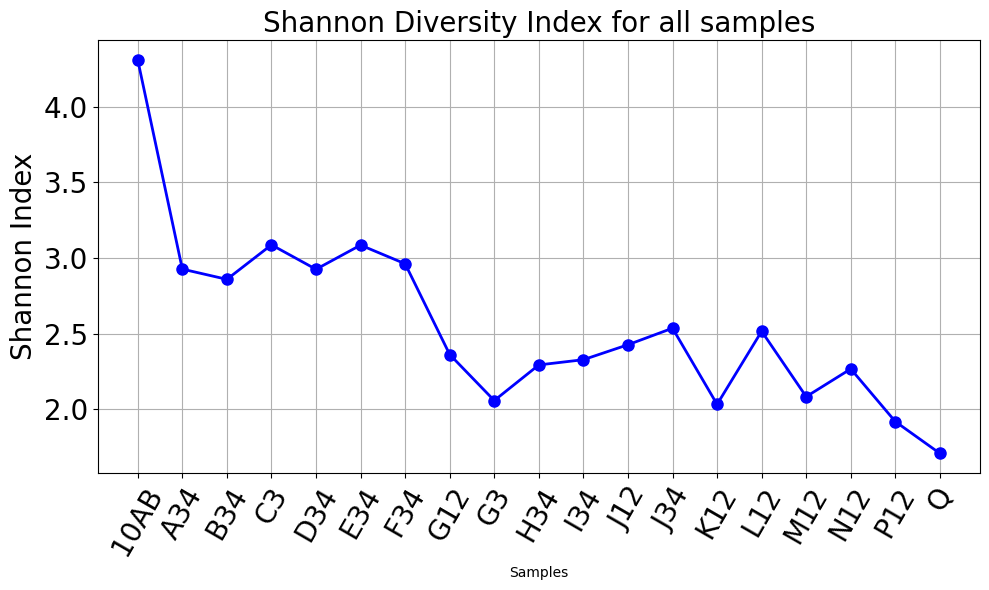

In [10]:
import matplotlib.pyplot as plt
from numpy import array, log
from json import load

asvSet_abundances = load(open(f"modeling_files/ASVset_abundances.json", 'r'))

SDI = {}
for sample, asvAbund in asvSet_abundances.items():
    abundances = array(list(asvAbund.values()))
    abundances /= sum(abundances)
    SDI[sample] = -sum(log(abundances)*abundances)

plt.figure(figsize=(10, 6))
plt.plot(SDI.keys(), SDI.values(), marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
plt.xlabel('Samples')
plt.ylabel('Shannon Index', fontsize=20)
plt.title('Shannon Diversity Index for all samples', fontsize=20)
plt.grid(True)
plt.yticks(fontsize=20)  # Rotate labels if needed
plt.xticks(rotation=60, fontsize=20)  # Rotate labels if needed
plt.tight_layout()
plt.show()

## Abundance heatmaps

max 52.3364486
max 0.523364486
[0, np.float64(0.01), np.float64(0.0266072505979881), np.float64(0.0707945784384138), np.float64(0.18836490894898), np.float64(0.5011872336272722)]


{149: {'Methanobacterium': 0.42693181450999995,
  nan: 0.32333466122999976,
  'Aminivibrio': 0.029317714449999997,
  'Mesotoga': 0.025011035860000003,
  'Desulfovibrio': 0.021797176970000005},
 161: {'Methanobacterium': 0.38578694492,
  nan: 0.36844447200999997,
  'Aminivibrio': 0.030832314790000002,
  'Lentimicrobium': 0.022546904650000005,
  'Mesotoga': 0.022031530749999997},
 182: {nan: 0.4604555896700001,
  'Methanobacterium': 0.37198632748000005,
  'Desulfovibrio': 0.0177623488,
  'Petrimonas': 0.01563184547,
  'Aminivibrio': 0.01423078377},
 189: {nan: 0.3852027539599999,
  'Methanobacterium': 0.34244847970000003,
  'Lentimicrobium': 0.039486596570000004,
  'Aminivibrio': 0.021907940560000002,
  'Petrimonas': 0.01459062109},
 210: {'Methanobacterium': 0.5982793539399999,
  nan: 0.13175205122999994,
  'Lentimicrobium': 0.07447442809,
  'Aminivibrio': 0.03078720523,
  'Petrimonas': 0.01773993815},
 238: {'Methanobacterium': 0.5410071720100001,
  nan: 0.18499238632,
  'Lentimicrobiu

{'Methanobacterium': 'Archaea|Euryarchaeota|Methanobacteria|Methanobacteriales|Methanobacteriaceae|Methanobacterium',
 nan: 'Archaea|Euryarchaeota|Methanobacteria|Methanobacteriales|Methanobacteriaceae|nan',
 'Mesotoga': 'Bacteria|Thermotogota|Thermotogae|Kosmotogales|Kosmotogaceae|Mesotoga',
 'Lentimicrobium': 'Bacteria|Bacteroidota|Bacteroidia|Sphingobacteriales|Lentimicrobiaceae|Lentimicrobium',
 'Aminivibrio': 'Bacteria|Synergistota|Synergistia|Synergistales|Synergistaceae|Aminivibrio',
 'midas_g_94288': 'Bacteria|Firmicutes|Clostridia|Gracilibacteraceae|Lutispora|midas_g_94288',
 'Desulfovibrio': 'Bacteria|Desulfobacterota|Desulfovibrionia|Desulfovibrionales|Desulfovibrionaceae|Desulfovibrio',
 'Petrimonas': 'Bacteria|Bacteroidota|Bacteroidia|Bacteroidales|Dysgonomonadaceae|Petrimonas'}

,149,161,182,189,210,238,283,300
Methanobacterium,0.426932,0.385787,0.371986,0.342448,0.598279,0.541007,0.561008,0.684422
NaN,0.323335,0.368444,0.460456,0.385203,0.131752,0.184992,0.232855,0.141047
Aminivibrio,0.029318,0.030832,0.014231,0.021908,0.030787,0.025389,0.000000,0.015118
Mesotoga,0.025011,0.022032,0.000000,0.000000,0.000000,0.000000,0.000000,0.046156
Desulfovibrio,0.021797,0.000000,0.017762,0.000000,0.000000,0.000000,0.000000,0.000000
Lentimicrobium,0.000000,0.022547,0.000000,0.039487,0.074474,0.079463,0.029221,0.018711
Petrimonas,0.000000,0.000000,0.015632,0.014591,0.017740,0.015630,0.018771,0.000000
midas_g_94288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015667,0.000000


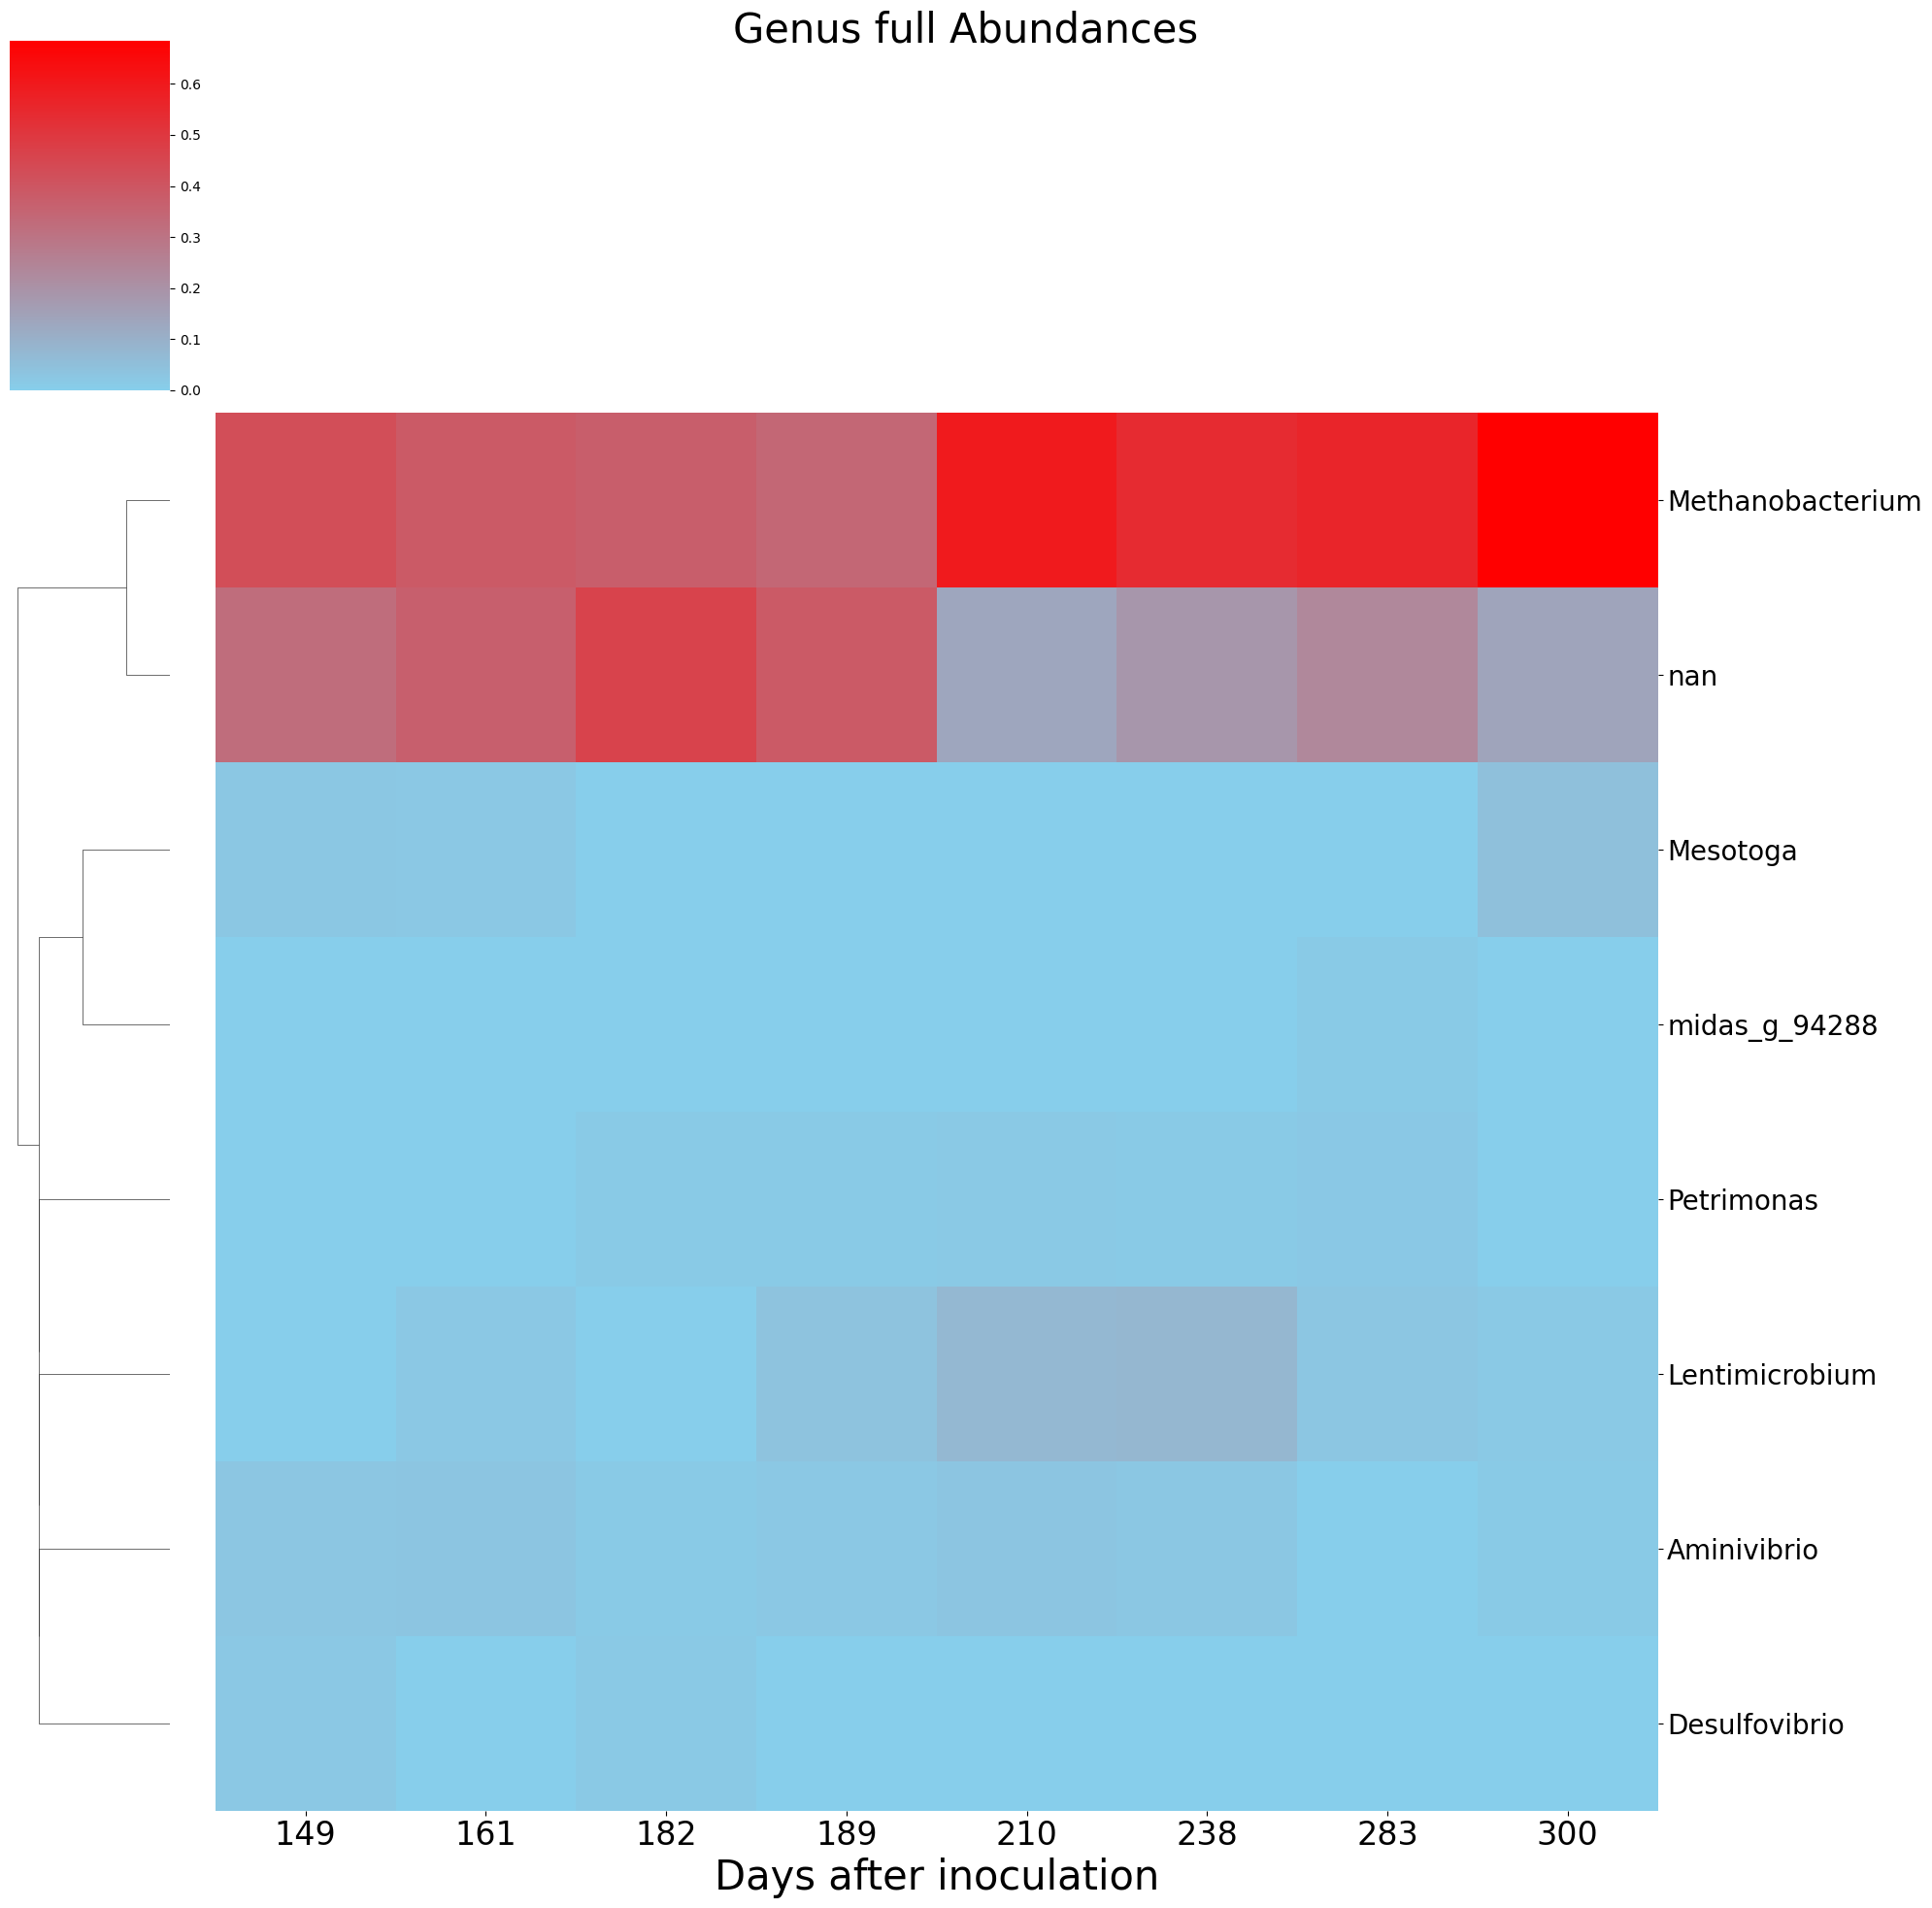

In [ ]:
from pandas import read_csv, DataFrame, Series, concat
import seaborn as sns
from matplotlib import pyplot
from json import load
from numpy import inf, nan, empty, logspace, log
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
from collections import Counter

# taxonomy = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/new_abundances.json", 'r'))

def taxonomy_linkage(taxonomy_series, ranks=('kingdom','phylum','class','order','family','genus','species'),
                     method: str = 'average'):
    """
    Build a SciPy linkage matrix from a taxonomy Series by defining
    a simple distance: (#ranks) - (#equal ranks at the same positions).

    Parameters
    ----------
    taxonomy_series : pd.Series
        Index order must match df.index (rows). Values are taxonomy strings
        like "k__Bacteria;p__Firmicutes;c__Bacilli;...".
    ranks : tuple or int
        Number of ranks considered. If tuple, its length is used.
    method : str
        Linkage method for scipy.cluster.hierarchy.linkage.

    Returns
    -------
    Z : np.ndarray
        Linkage matrix suitable for seaborn.clustermap(row_linkage=Z).
    """
    # Normalize rank count
    ranks_n = len(ranks) if not isinstance(ranks, int) else int(ranks)

    # Split and standardize to fixed-length lists (pad/truncate)
    parts = (
        taxonomy_series.fillna("")
        .astype(str)
        .str.split(r"[;|,]", regex=True)
        .apply(lambda lst: [x.strip() for x in (lst or [])])
        .apply(lambda lst: (lst + [""] * ranks_n)[:ranks_n])
    )

    n = len(parts)
    if n <= 1:
        # Nothing to cluster; return empty linkage
        return empty((0, 4), dtype=float)

    # Build condensed distance vector: distance = ranks_n - (#equal positions)
    D_condensed = []
    for i in range(n - 1):
        ai = parts.iloc[i]  # POSitional access fixes KeyError
        for j in range(i + 1, n):
            aj = parts.iloc[j]
            same = sum(a == b and a != "" and b != "" for a, b in zip(ai, aj))
            D_condensed.append(ranks_n - same)

    # Convert to linkage (hierarchical clustering tree)
    Z = linkage(D_condensed, method=method)
    return Z


def concatenate_taxonomy(df, level):
    dic = {}
    for index, row in df.iterrows():
        dic["|".join([str(row[l]) for l in taxonomic_levels
                    if taxonomic_levels.index(l) <= taxonomic_levels.index(level)])] = index
    return Series(dic)

def change_columns(df):
    return df[[c for c in sample_days.values() if c in df.columns]]
    # return df[[c for c in sample_days if c in df.columns]]


from matplotlib.colors import LinearSegmentedColormap

# ab = read_csv("GAME Sequencing/ASV_abundance_wideform.csv").set_index("seq")
taxonomic_levels = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
sample_days = {
    "10AB": 0,
    # "A34": 22,
    # "B34": 35,
    # "C3": 69,
    # "D34": 83,
    # "E34": 91,
    # "F34": 105,
    # "G12": 126,
    # "G3": 126,
    # "H34": 140,
    "I34": 149,
    "J12": 161,
    # "J34": 126,
    "K12": 182,
    "L12": 189,
    "M12": 210,
    "N12": 238,
    "P12": 283,
    "Q": 300
}

total_df = read_csv("model_inputs/total.csv").set_index("seq")
max_abundance = total_df["rel_ab"].max()
print("max", max_abundance)
# sample_dfs = []
# for sample in sample_days:
#     sample_og = og[og["sample"] == sample]
#     sample_og["rel_ab"] = sample_og["rel_ab"] / sample_og["rel_ab"].sum()
#     sample_dfs.append(sample_og)
# og = concat(sample_dfs)
total_df["rel_ab"] /= 100
max_abundance = total_df["rel_ab"].max()
print("max", max_abundance)
intervals = [0] + list(logspace(-2, -.3, 5))
print(intervals)


def create_heatmap(df, level, abundance_range, taxonomies, cmap=None, log=False):
    # min_abundance = min(list(df.to_numpy().flatten()))
    # max_abundance = max(list(df.to_numpy().flatten()))
    # new_cmap = LinearSegmentedColormap.from_list("NewMap", [(0, "skyblue"), (1, "red")])
    # if log:
    cmap = cmap or LinearSegmentedColormap.from_list("NewMap", ["skyblue", "red"])
    # display(df)
    # clustermap = ClusterHeatmap(df, level, ) # Series(dict(Counter(taxonomies))))
    clusterMap = sns.clustermap(df,
                                # row_colors=row_colors,
                                cmap=cmap,
                                vmin=0,
                                vmax=max(list(df.to_numpy().flatten())),
                                col_cluster=False, figsize=(20, 20),
                                row_linkage=taxonomy_linkage(Series(taxonomies)),
                                dendrogram_ratio=(.1, .2))
    clusterMap.figure.subplots_adjust(bottom=0.15, top=0.95)  # Adjust these values as needed to fit labels
    clusterMap.figure.suptitle(f"{level.capitalize()} {abundance_range} Abundances", fontsize=30)
    clusterMap.ax_heatmap.set_yticklabels(clusterMap.ax_heatmap.get_yticklabels(), fontsize=20, rotation=0)
    clusterMap.ax_heatmap.set_xticklabels(clusterMap.ax_heatmap.get_xticklabels(), fontsize=24)
    clusterMap.ax_heatmap.set_xlabel("Days after inoculation", fontsize=30)
    clusterMap.figure.tight_layout()
    clusterMap.figure.savefig(f"abundance_heatmaps/{level}_{abundance_range}_abundances.png")

# taxa- and abundance-level heatmaps
for i, abundance_limit in enumerate(intervals):
    if abundance_limit == 0:  continue
    previous_limit = intervals[i-1]
    print(previous_limit, abundance_limit)
    abundance_range = f"{round(previous_limit, 2)}-{round(abundance_limit, 2)}"
    for level in taxonomic_levels:
        # ab = ab.set_index(level).drop([l for l in taxonomic_levels if l != level], axis=1)#.groupby(level).sum()
        # display(ab)

        dic = {}
        taxonomies = {}
        for seq, row in total_df.iterrows():
            # for s, abundance in row.items():
            day = sample_days.get(row["sample"])
            if not day:  continue
            
            # print(abundance)
            abundance = row["rel_ab"]
            if abundance <= previous_limit or abundance > abundance_limit:  continue

            taxonomies.setdefault(row[level], "|".join([str(row[l]) for l in taxonomic_levels
                                    if taxonomic_levels.index(l) <= taxonomic_levels.index(level)]))
            dic.setdefault(day, {})
            dic[day].setdefault(row[level], 0)
            dic[day][row[level]] += abundance

        # display(dic)
        if dic == {}:
            print(f"The {level} does not have organisms in {abundance_range}")
            continue
        elif len(taxonomies) == 1:
            print(f"The {level} only has one organism in {abundance_range}:  {dic} and {taxonomies}")
            continue

        # display(dic)

        df = change_columns(DataFrame(dic))
        df = df.astype(float).replace([inf, -inf], nan).fillna(0)
        # display(df)
        # display(df.to_numpy())
        # max_abundance = max(list(df.to_numpy().flatten()))
        # display(df)
        create_heatmap(df, level, abundance_range, taxonomies)
        # clustermap = ClusterHeatmap(df, level, ) # Series(dict(Counter(taxonomies))))
        # clusterMap = sns.clustermap(df, 
        #                             # row_colors=row_colors,
        #                             cmap=new_cmap,
        #                             vmin=0,
        #                             vmax=max_abundance,
        #                             col_cluster=False, figsize=(20, 20),
        #                             row_linkage=taxonomy_linkage(Series(taxonomies)),
        #                             dendrogram_ratio=(.1, .2))
        # clusterMap.figure.subplots_adjust(bottom=0.15, top=0.95)  # Adjust these values as needed to fit labels
        # clusterMap.figure.suptitle(f"{level.capitalize()} {abundance_range} Abundances", fontsize=30)
        # clusterMap.ax_heatmap.set_yticklabels(clusterMap.ax_heatmap.get_yticklabels(), fontsize=20, rotation=0)
        # clusterMap.ax_heatmap.set_xticklabels(clusterMap.ax_heatmap.get_xticklabels(), fontsize=24)
        # clusterMap.ax_heatmap.set_xlabel("Days after inoculation", fontsize=30)
        # clusterMap.figure.tight_layout()
        # clusterMap.figure.savefig(f"abundance_heatmaps/{level}_{abundance_range}_abundances.png")

#### Making Heather's requested figures

In [ ]:
from numpy import log10

def create_heatmap(df, taxonomies, title):
    new_cmap = LinearSegmentedColormap.from_list("NewMap", ["skyblue", "red"])
    # display(df)
    # clustermap = ClusterHeatmap(df, level, ) # Series(dict(Counter(taxonomies))))
    clusterMap = sns.clustermap(df,
                                # row_colors=row_colors,
                                cmap=new_cmap,
                                cbar_kws={"label": "Relative Abundance"},
                                # vmin=0,
                                # vmax=max(list(df.to_numpy().flatten())),
                                col_cluster=False, figsize=(20, 20),
                                row_linkage=taxonomy_linkage(Series(taxonomies)),
                                dendrogram_ratio=(.1, .2))
    
    # Now customize the colorbar to show ORIGINAL (non-log) values
    cbar = clusterMap.ax_cbar
    log_ticks = cbar.get_yticks()
    original_ticks = 10**log_ticks  # or just 10**log_ticks if no +pseudocount
    original_labels = [f"{x:.1e}" if x < 0.01 else f"{x:.3f}" for x in original_ticks]
    cbar.set_yticklabels(original_labels)
    cbar.set_yticks(log_ticks)  # already there, but ensure

    clusterMap.figure.subplots_adjust(bottom=0.15, top=0.95)  # Adjust these values as needed to fit labels
    clusterMap.figure.suptitle(title, fontsize=30)
    clusterMap.ax_heatmap.set_yticklabels(clusterMap.ax_heatmap.get_yticklabels(), fontsize=20, rotation=0)
    clusterMap.ax_heatmap.set_xticklabels(clusterMap.ax_heatmap.get_xticklabels(), fontsize=24)
    clusterMap.ax_heatmap.set_xlabel("Days after inoculation", fontsize=30)
    clusterMap.figure.tight_layout()
    clusterMap.figure.savefig(f"abundance_heatmaps/{title.lower().replace(' ', '_')}.png")

dic = {}
taxonomies = {}
level = "Genus"
for seq, row in total_df.iterrows():
    day = sample_days.get(row["sample"])
    if row["Kingdom"] == "Bacteria" or not day:  continue
    
    abundance = row["rel_ab"]
    if abundance == 0:  continue
    taxonomies.setdefault(row[level], "|".join([str(row[l]) for l in taxonomic_levels
                                    if taxonomic_levels.index(l) <= taxonomic_levels.index(level)]))
    dic.setdefault(day, {})
    dic[day].setdefault(row[level], 0)
    dic[day][row[level]] += abundance

new_dic = {}
for day, content in dic.items():
    new_dic[day] = {genus: log10(abund) for genus, abund in content.items()}

df = change_columns(DataFrame(new_dic))
display(df)
df = df.astype(float).replace([inf, -inf], nan).fillna(0)
create_heatmap(df, taxonomies, "Methanogens Abundances")


# Create a single Genus-level heatmap
#TODO:  Make this figure logarithmic to ensure that all organisms can be perceived
from numpy import log10
dic, taxonomies = {}, {}
for seq, row in total_df.iterrows():
    day = sample_days.get(row["sample"])
    if not day:  continue
    taxonomies.setdefault(row["Genus"], "|".join([str(row[l]) for l in taxonomic_levels
                            if taxonomic_levels.index(l) <= taxonomic_levels.index("Genus")]))
    dic.setdefault(day, {})
    dic[day].setdefault(row["Genus"], 0)
    dic[day][row["Genus"]] += row["rel_ab"]

nonzero_per_day = {
    day: dict(sorted({k:v for k,v in org_dict.items() if v>0}.items(), key=lambda item: item[1], reverse=True))
    for day, org_dict in dic.items()
}
dump(nonzero_per_day, open("model_inputs/nonzero_per_day.json", "w"), indent=2)
top5_per_day = {}
all_orgs = {}
for day, org_dict in nonzero_per_day.items():
    orgs = dict(list(org_dict.items())[:5])
    top5_per_day[day] = {k:log10(v) for k,v in orgs.items()}
    all_orgs.update(orgs)
taxonomies = {org:taxa for org, taxa in taxonomies.items() if org in all_orgs}
display(top5_per_day)
display(taxonomies)

# for day, content in dic.items():
#     dic[day] = {genus: log10(abund) for genus, abund in content.items()}
df = change_columns(DataFrame(top5_per_day))
df = df.astype(float).replace([inf, -inf], nan).fillna(0)
display(df)
create_heatmap(df, taxonomies, "All Genera")


In [ ]:
from numpy import log
from json import load, dump

def shannon_index(abundances):
    return -sum([abundance * log(abundance) for abundance in abundances if abundance > 0])

abundances_js = load(open("model_inputs/abundances.json", 'r'))
shannon_indices = {day: shannon_index(list(abundances.values())) for day, abundances in abundances_js.items()}
shannon_indices

{'10AB': np.float64(5.579575294259052),
 'A34': np.float64(3.2605600645745487),
 'B34': np.float64(3.263458942369893),
 'C3': np.float64(3.4012258902025234),
 'D34': np.float64(3.1937566677952622),
 'E34': np.float64(3.412032206067728),
 'F34': np.float64(3.239300670334497),
 'G12': np.float64(2.5959837718141836),
 'G3': np.float64(2.281451568444167),
 'H34': np.float64(2.5694754655567325),
 'I34': np.float64(2.586176562401467),
 'J12': np.float64(2.692281892319374),
 'J34': np.float64(2.810395305416235),
 'K12': np.float64(2.2467661240221264),
 'L12': np.float64(2.7615664541563443),
 'M12': np.float64(2.360296248953222),
 'N12': np.float64(2.529054814966601),
 'P12': np.float64(2.239845944467726),
 'Q': np.float64(1.8945603929813053)}

In [ ]:
# from pandas import read_csv, DataFrame, Series, concat
# import seaborn as sns
# from matplotlib import pyplot
# from json import load
# from numpy import inf, nan, empty, logspace
# from scipy.spatial.distance import squareform
# from scipy.cluster.hierarchy import linkage
# from collections import Counter

# # taxonomy = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/new_abundances.json", 'r'))

# def taxonomy_linkage(taxonomy_series, ranks=('kingdom','phylum','class','order','family','genus','species'),
#                      method: str = 'average'):
#     """
#     Build a SciPy linkage matrix from a taxonomy Series by defining
#     a simple distance: (#ranks) - (#equal ranks at the same positions).

#     Parameters
#     ----------
#     taxonomy_series : pd.Series
#         Index order must match df.index (rows). Values are taxonomy strings
#         like "k__Bacteria;p__Firmicutes;c__Bacilli;...".
#     ranks : tuple or int
#         Number of ranks considered. If tuple, its length is used.
#     method : str
#         Linkage method for scipy.cluster.hierarchy.linkage.

#     Returns
#     -------
#     Z : np.ndarray
#         Linkage matrix suitable for seaborn.clustermap(row_linkage=Z).
#     """
#     # Normalize rank count
#     ranks_n = len(ranks) if not isinstance(ranks, int) else int(ranks)

#     # Split and standardize to fixed-length lists (pad/truncate)
#     parts = (
#         taxonomy_series.fillna("")
#         .astype(str)
#         .str.split(r"[;|,]", regex=True)
#         .apply(lambda lst: [x.strip() for x in (lst or [])])
#         .apply(lambda lst: (lst + [""] * ranks_n)[:ranks_n])
#     )

#     n = len(parts)
#     if n <= 1:
#         # Nothing to cluster; return empty linkage
#         return empty((0, 4), dtype=float)

#     # Build condensed distance vector: distance = ranks_n - (#equal positions)
#     D_condensed = []
#     for i in range(n - 1):
#         ai = parts.iloc[i]  # POSitional access fixes KeyError
#         for j in range(i + 1, n):
#             aj = parts.iloc[j]
#             same = sum(a == b and a != "" and b != "" for a, b in zip(ai, aj))
#             D_condensed.append(ranks_n - same)

#     # Convert to linkage (hierarchical clustering tree)
#     Z = linkage(D_condensed, method=method)
#     return Z


# def concatenate_taxonomy(df, level):
#     dic = {}
#     for index, row in df.iterrows():
#         dic["|".join([str(row[l]) for l in taxonomic_levels
#                     if taxonomic_levels.index(l) <= taxonomic_levels.index(level)])] = index
#     return Series(dic)

# def change_columns(df):
#     return df[[c for c in sample_days.values() if c in df.columns]]
#     # return df[[c for c in sample_days if c in df.columns]]


# from matplotlib.colors import LinearSegmentedColormap

# # Define a single-color gradient colormap (white → blue)
# new_cmap = LinearSegmentedColormap.from_list("NewMap", [(0, "skyblue"), (1, "red")])


# from pandas import read_excel
# from json import dump
# # ab = read_csv("GAME Sequencing/ASV_abundance_wideform.csv").set_index("seq")
# taxonomic_levels = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
# # sample_order = ["10AB", "A34", "B34", "C3", "D34", "E34", "F34", "G12", "G3", "H34", "I34",
# #                 "J12", #"J34",
# #                 "K12", "L12", "M12", "N12", "P12"]
# sample_days = {
#     "10AB": 0,
#     # "A34": 22,
#     # "B34": 35,
#     # "C3": 69,
#     # "D34": 83,
#     # "E34": 91,
#     # "F34": 105,
#     # "G12": 126,
#     # "G3": 126,
#     # "H34": 140,
#     "I34": 149,
#     "J12": 161,
#     # "J34": 126,
#     "K12": 182,
#     "L12": 189,
#     "M12": 210,
#     "N12": 238,
#     "P12": 283,
#     "Q": 300
# }

# og = read_csv("model_inputs/").set_index("seq")
# sample_dfs = []
# for sample in sample_days:
#     # print(sample)
#     sample_og = og[og["sample"] == sample]
#     # display(sample_og)
#     sample_og["rel_ab"] = sample_og["rel_ab"] / sample_og["rel_ab"].sum()
#     sample_dfs.append(sample_og)
# og = concat(sample_dfs)
# # og["rel_ab"] /= og["rel_ab"].sum()
# # max_abundance = og["rel_ab"].max()
# # print(max_abundance)
# # display(og)
# intervals = [0] + list(logspace(-2, -.3, 5))
# print(intervals)
# for i, abundance_limit in enumerate(intervals):
#     if abundance_limit == 0:  continue
#     previous_limit = intervals[i-1]
#     print(previous_limit, abundance_limit)
#     abundance_range = f"{round(previous_limit, 2)}-{round(abundance_limit, 2)}"
#     for level in taxonomic_levels:
#         ab = og.copy()
#         # ab = ab.set_index(level).drop([l for l in taxonomic_levels if l != level], axis=1)#.groupby(level).sum()
#         # display(ab)

#         dic = {}
#         taxonomies = {}
#         for seq, row in ab.iterrows():
#             s = row["sample"]
#             if s == "J34":  continue
            
#             day = sample_days[s]
#             abundance = row["rel_ab"]
#             # print(abundance)
#             if abundance <= previous_limit or abundance > abundance_limit:  continue
#             # asvs_used.append(row["seq"])
#             taxonomies[row[level]] = "|".join([str(row[l]) for l in taxonomic_levels
#                                 if taxonomic_levels.index(l) <= taxonomic_levels.index(level)])
#             # taxonomies.append("|".join([str(row[l]) for l in taxonomic_levels
#             #                     if taxonomic_levels.index(l) <= taxonomic_levels.index(level)]))
#             dic.setdefault(day, {})
#             dic[day].setdefault(row[level], 0)
#             dic[day][row[level]] += abundance

#         # display(dic)
#         if dic == {}:
#             print(f"The {level} does not have organisms in {abundance_range}")
#             continue
#         elif len(taxonomies) == 1:
#             print(f"The {level} only has one organism in {abundance_range}:  {dic} and {taxonomies}")
#             continue

#         # display(dic)

#         df = change_columns(DataFrame(dic))
#         df = df.astype(float).replace([inf, -inf], nan).fillna(0)
#         # display(df)
#         # display(df.to_numpy())
#         max_abundance = max(list(df.to_numpy().flatten()))
#         # display(df)
#         # clustermap = ClusterHeatmap(df, level, ) # Series(dict(Counter(taxonomies))))
#         clusterMap = sns.clustermap(df, 
#                                     # row_colors=row_colors,
#                                     cmap=new_cmap,
#                                     vmin=0,
#                                     vmax=max_abundance,
#                                     col_cluster=False, figsize=(20, 20),
#                                     row_linkage=taxonomy_linkage(Series(taxonomies)),
#                                     dendrogram_ratio=(.1, .2))
#         clusterMap.figure.subplots_adjust(bottom=0.15, top=0.95)  # Adjust these values as needed to fit labels
#         clusterMap.figure.suptitle(f"{level.capitalize()} {abundance_range} Abundances", fontsize=30)
#         clusterMap.ax_heatmap.set_yticklabels(clusterMap.ax_heatmap.get_yticklabels(), fontsize=20, rotation=0)
#         clusterMap.ax_heatmap.set_xticklabels(clusterMap.ax_heatmap.get_xticklabels(), fontsize=24)
#         clusterMap.ax_heatmap.set_xlabel("Days after inoculation", fontsize=30)
#         clusterMap.figure.tight_layout()
#         clusterMap.figure.savefig(f"abundance_heatmaps/{level}_{abundance_range}_abundances.png")
#     # break

# Correlate member abundances with methane

In [ ]:
merged_correlations = {}
for index, row in merged_normalized_abundances.iterrows():
    corr = row.corr(normalized_methane)
    merged_correlations[index] = corr
    # print(f"{index} correlates {corr} with methane")

merged_correlations = dict(sorted(merged_correlations.items(), key=lambda item: item[1], reverse=True))
merged_correlations

In [59]:
from pandas import DataFrame, Series, isna
from json import load, dump

iterativeIDs = load(open("model_inputs/iterativeIDs.json", 'r'))
abundances = load(open("model_inputs/abundances.json", 'r'))
asvSet_abundances = load(open(f"modeling_files/ASVset_abundances.json", 'r'))
omitted_columns = {"all_relevant_samples": ["10AB", "A34", "B34", "C3", "D34", "E34", "F34", "G12", "G3", "H34"],
                   "stable_phase": ["10AB", "A34", "B34", "C3", "D34", "E34", "F34", "G12", "G3", "H34", "I34", "J12", "J34", "Q"]}

for dataName, term in {"purity": "Gas Composition (% CH4)", "production": "CH4 Production (mol/min)"}.items():
    for name, ommitted in omitted_columns.items():
        abundances_df = DataFrame(abundances).drop(ommitted, axis=1)
        abundances_df = abundances_df.loc[~(abundances_df < 0.001).all(axis=1)]
        display(abundances_df)
        summary_samples = load(open("model_inputs/measurements/summary_samples.json", 'r'))
        sample_methane = {sample: content[term] for sample, content in summary_samples.items()
                         if sample not in omitted_columns}
        print(sample_methane)
        
        # ASV correlations
        ASV_correlations = {}
        for ASV, sampleAbun in abundances_df.iterrows():
            ID = iterativeIDs.get(ASV, ASV)
            correlation = sampleAbun.corr(Series(sample_methane))
            if isna(correlation):  continue
            ASV_correlations[ID] = correlation
        
        ASV_correlations = dict(sorted(ASV_correlations.items(), key=lambda item: item[1], reverse=True))
        dump(ASV_correlations, open(f"modeling_files/correlations/ASV_correlations_{name}_{dataName}.json", 'w'))
        
        # ASVset correlations
        ASVset_abundances_df = DataFrame(asvSet_abundances).drop(ommitted, axis=1).fillna(0)
        display(ASVset_abundances_df)
        ASVset_correlations = {}
        for ASV, sampleAbun in ASVset_abundances_df.iterrows():
            ID = iterativeIDs.get(ASV, ASV)
            correlation = sampleAbun.corr(Series(sample_methane))
            if isna(correlation):  continue
            ASVset_correlations[ID] = correlation
        
        ASVset_correlations = dict(sorted(ASVset_correlations.items(), key=lambda item: item[1], reverse=True))
        dump(ASVset_correlations, open(f"modeling_files/correlations/ASVset_correlations_{name}_{dataName}.json", 'w'))
        
        
        # IterativeID correlations
        ASVset_abundances_df.index = [iterativeIDs.get(ASV,ASV).split(".")[0] for ASV in ASVset_abundances_df.index]
        ASVset_abundances_df.groupby(ASVset_abundances_df.index).sum()
        display(ASVset_abundances_df)
        IterativeID_correlations = {}
        for genus, sampleAbun in ASVset_abundances_df.iterrows():
            correlation = sampleAbun.corr(Series(sample_methane))
            if isna(correlation):  continue
            IterativeID_correlations[genus] = correlation
        
        IterativeID_correlations = dict(sorted(IterativeID_correlations.items(), key=lambda item: item[1], reverse=True))
        dump(IterativeID_correlations, open(f"modeling_files/correlations/IterativeID_correlations_{name}_{dataName}.json", 'w'))

,I34,J12,J34,K12,L12,M12,N12,P12,Q
593b39ccba286d62eba7872e07c45354,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002530,0.000000
e1c573f885ed4c9191a32116f583d78a,0.102822,0.161653,0.130276,0.031802,0.045830,0.032588,0.007362,0.003795,0.003822
65c689dc4b8772012494d43535fd1102,0.028532,0.012392,0.017524,0.004448,0.019679,0.002414,0.002906,0.000000,0.000000
1a33b954694a3eddcd95ead6c562cfb2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001107,0.000000
06246fa4c1b00ea76b5539442f32c012,0.028532,0.020277,0.030206,0.000000,0.001295,0.009414,0.002906,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
46984bc1f36f8a8835a4a7914c2502b2,0.000000,0.004224,0.000000,0.000000,0.000000,0.001931,0.000000,0.003795,0.000000
0484af5151bcaaad02766e19dd985537,0.000000,0.000000,0.001614,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
271bd4b9da94143ce8501f14bb3f6ab4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001550,0.000000,0.000000
923d1e7b6ceac97721615d80cf869780,0.000000,0.000000,0.003459,0.000000,0.000000,0.000000,0.004456,0.001739,0.000000


{'10AB': 0.0, 'A34': 0.4049563333333333, 'B34': 0.2709499999999999, 'C3': 0.7750533183227921, 'D34': 0.7559866666666666, 'E34': 0.805937, 'F34': 0.908542, 'G12': 0.953264, 'H34': 0.9826696666666668, 'I34': 0.716158, 'J12': 0.9120056666666668, 'K12': 0.919604, 'L12': 0.948323, 'M12': 0.946802, 'N12': 0.951829, 'P12': 0.8886636666666667, 'Q': 0.9296366666666666}


/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encount

,I34,J12,J34,K12,L12,M12,N12,P12,Q
9f86297104372f6378c6bf3dc1a8e8ec,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
acb819d2b09f090ba6c3112028bbc54b,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1f1ff56fd37c5c9b1a9ac7b1d99e10b0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
496ed1835247fa310353bd53160fad4a,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
18ec5da6c765ede0c426af393f8ce656,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
945e47119242497c2e0bc5b3c6b6ba8e,0.0,0.0,0.0,0.0,0.0,0.0,0.001389,0.001490,0.001854
1d33e98c9d94c262ab0d8b56d0936eb4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.001545,0.001873
1ad05a58bf23396d80f11695ad750b75,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.001464,0.000000
916d15ab17794198ea4c5ad1e3fb6258,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.002002,0.001032


/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encount

...

{'10AB': 0.0, 'A34': 9.175707686634614e-06, 'B34': 6.680376217349626e-06, 'C3': 2.93696161770516e-05, 'D34': 2.75813753149924e-05, 'E34': 3.363534760587931e-05, 'F34': 2.0663129022454387e-05, 'G12': 1.0095558793717763e-05, 'H34': 1.1512598643109726e-05, 'I34': 1.1248033364647425e-05, 'J12': 1.1936750170568826e-05, 'K12': 1.2460364201611604e-05, 'L12': 1.2848173821886422e-05, 'M12': 1.5171651820270254e-05, 'N12': 1.6302835661241578e-05, 'P12': 2.872552315028346e-05, 'Q': 2.860058816882215e-05}


,K12,L12,M12,N12,P12
9f86297104372f6378c6bf3dc1a8e8ec,0.0,0.0,0.0,0.000000,0.000000
acb819d2b09f090ba6c3112028bbc54b,0.0,0.0,0.0,0.000000,0.000000
1f1ff56fd37c5c9b1a9ac7b1d99e10b0,0.0,0.0,0.0,0.000000,0.000000
496ed1835247fa310353bd53160fad4a,0.0,0.0,0.0,0.000000,0.000000
18ec5da6c765ede0c426af393f8ce656,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...
945e47119242497c2e0bc5b3c6b6ba8e,0.0,0.0,0.0,0.001389,0.001490
1d33e98c9d94c262ab0d8b56d0936eb4,0.0,0.0,0.0,0.000000,0.001545
1ad05a58bf23396d80f11695ad750b75,0.0,0.0,0.0,0.000000,0.001464
916d15ab17794198ea4c5ad1e3fb6258,0.0,0.0,0.0,0.000000,0.002002


/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encount

,K12,L12,M12,N12,P12
midas_g_4042,0.0,0.0,0.0,0.000000,0.000000
midas_g_269,0.0,0.0,0.0,0.000000,0.000000
midas_g_52,0.0,0.0,0.0,0.000000,0.000000
OPB41,0.0,0.0,0.0,0.000000,0.000000
midas_g_531,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...
Aminiphilus,0.0,0.0,0.0,0.001389,0.001490
Hydrogenophaga,0.0,0.0,0.0,0.000000,0.001545
Geobacteraceae,0.0,0.0,0.0,0.000000,0.001464
Desulfurispora,0.0,0.0,0.0,0.000000,0.002002


/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/afreiburger/repos/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encount